In [1]:
using Oceananigans
using NCDatasets
using Printf
using CairoMakie
using Oceananigans.Fields
using Oceananigans.AbstractOperations: volume
using NaNStatistics

In [2]:
using TopographicHorizontalConvection
using TopographicHorizontalConvection: HorizontalConvectionSimulation

In [3]:
ds_buoy = NCDataset("/pub/ikeshwan/code/HorizontalConvection/output/turbulent_h0.6_Ra1.0e8_coldstart_buoyancy.nc");
ds_vel = NCDataset("/pub/ikeshwan/code/HorizontalConvection/output/turbulent_h0.6_Ra1.0e8_coldstart_velocities.nc");

# Calculation of Fluxes

#### Reversible Vertical Buoyancy Flux:  
$ \phi_z = \int \rho g w dV \rightarrow -\int b w dV $

#### Rate of conversion from internal to potential energy:   
$ \phi_i = -\kappa g A (\bar{\rho}_{top} - \bar{\rho}_{bottom})$

#### Rate of change of background potential due to diapycnal mixing : 
$ \phi_d = \kappa g \int - \frac{dz_*}{d \rho} \left | \nabla \rho \right |^2 dV$

In [7]:
#vertical buoyancy flux

b = ds_buoy["b"][4+1:end-4, 1, 4+1:end-4, :];
w = ds_vel["w"][4+1:end-4, 1, 5+1:end-4, :];

bw = b .* w;

In [39]:
#integrate bw over volume -- reimann sum

x = ds_buoy["xC"][4+1:end-4]; Nx = length(x);
y = ds_buoy["yC"][:]; Ny =  length(y)
z = ds_buoy["zC"][4+1:end-4]; Nz = length(z);

H = 1.0;
Ly = H/4;
Δy = Ly/Ny;

In [52]:
bw = reshape(bw, Nx, Ny, Nz, length(time));

time = ds_buoy["time"][:];
Δx = reshape(diff(ds_buoy["xF"])[4+1:end-4], Nx,1,1);
Δz = reshape(diff(ds_buoy["zF"])[4+1:end-4], 1, 1, Nz);
ΔA = Δx .* Δy;
ΔV = ΔA .* Δz;

In [53]:
ϕ_z = zeros(size(time,1));
for n in 1:size(time, 1)
    bw_t = -1 .* bw[:, 1, :, n]
    wet = bw_t.!=0
    bw_t[.!wet] .= NaN
    ϕ_z[n] = nansum(
        bw_t .*
        ΔV, 
        dims=(3)
        )[1,1,1]
end

ϕ_z

201-element Vector{Float64}:
  0.0
 -1.640155497370986e-16
 -3.281584130785281e-16
 -4.923134757270158e-16
 -6.564700797057861e-16
 -8.206263243248323e-16
 -9.847818216913833e-16
 -1.1489364912461876e-15
 -1.3130903158068984e-15
 -1.4772432906943492e-15
 -1.641395415816761e-15
 -1.805546690908704e-15
 -1.9696971161027007e-15
  ⋮
 -3.101093337485191e-14
 -3.1174932532307413e-14
 -3.133893083941285e-14
 -3.150292829859457e-14
 -3.16669249083063e-14
 -3.183092066682831e-14
 -3.199491557786752e-14
 -3.215890963863325e-14
 -3.232290284979345e-14
 -3.2486895211799036e-14
 -3.265088672344397e-14
 -3.281487738727021e-14

### Next, let's calculate $\phi_i$

#### Rate of conversion from internal to potential energy:   
$ \phi_i = -\kappa g A (\bar{\rho}_{top} - \bar{\rho}_{bottom}) \rightarrow \kappa A (b_{top} - b_{bottom}) $

In [54]:
b_bottom = TopographicHorizontalConvection.buoyancy_level_avg(ds_buoy, "bottom");
b_top = TopographicHorizontalConvection.buoyancy_level_avg(ds_buoy, "top");
#I cant seem to figure out how to access global attributes from NetCDF files, but upon looking at ds_buoy we know kappa=0.0001
κ = 0.0001;
A = 8

ϕᵢ = (κ * A) .* (b_top .- b_bottom);

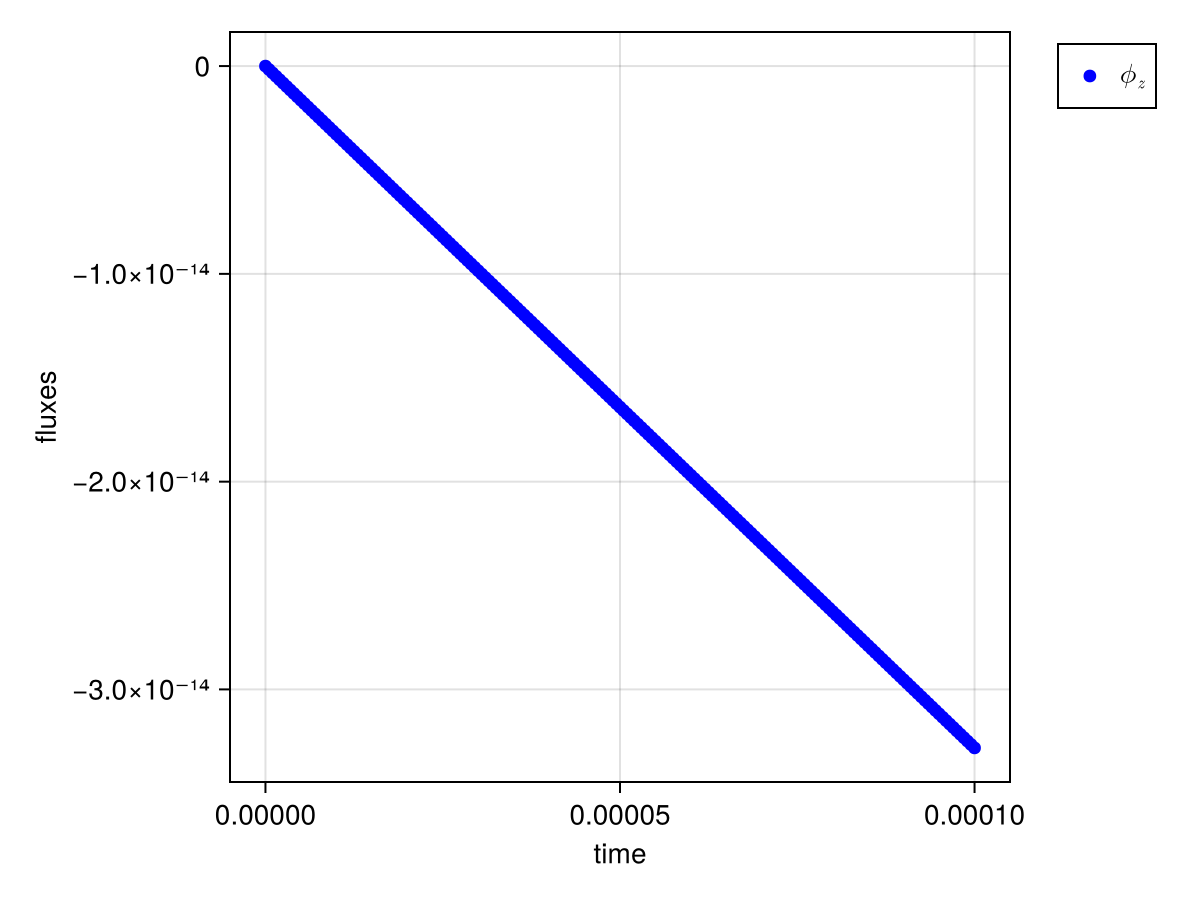

In [55]:
f = Figure()
ax = Axis(f[1,1], xlabel = "time", ylabel= "fluxes")
scatter!(ax, time, ϕ_z, color = "blue", label = L"\phi_z")
#scatter!(ax, time, ϕᵢ, color = "red", label = L"\phi_i")
f[1,2] = axislegend()
f

### Now for $ \phi_d $

#### Rate of change of background potential due to diapycnal mixing : 
$ \phi_d = \kappa g \int - \frac{dz_*}{d \rho} \left | \nabla \rho \right |^2 dV$

#### Method:

first, we need to calculate the flattened 1D arrays for z and b.
to find $z_*$ we need to sort through z and b. Refer to the background_potential_energy.ipynb notebook. 

In [22]:
#so we already have x, z, Δx, and Δz defined above

#since this is a cold start sim, we can use the initial timestep to create wet map
#because buoyancy is not initialized as zero everywhere! cool!
b = ds_buoy["b"][4+1:end-4, 1, 4+1:end-4, 1];
wet = b.!=0.

b[.!wet] .= NaN; #wherever the buoyancy is zero == hills == land == NaN

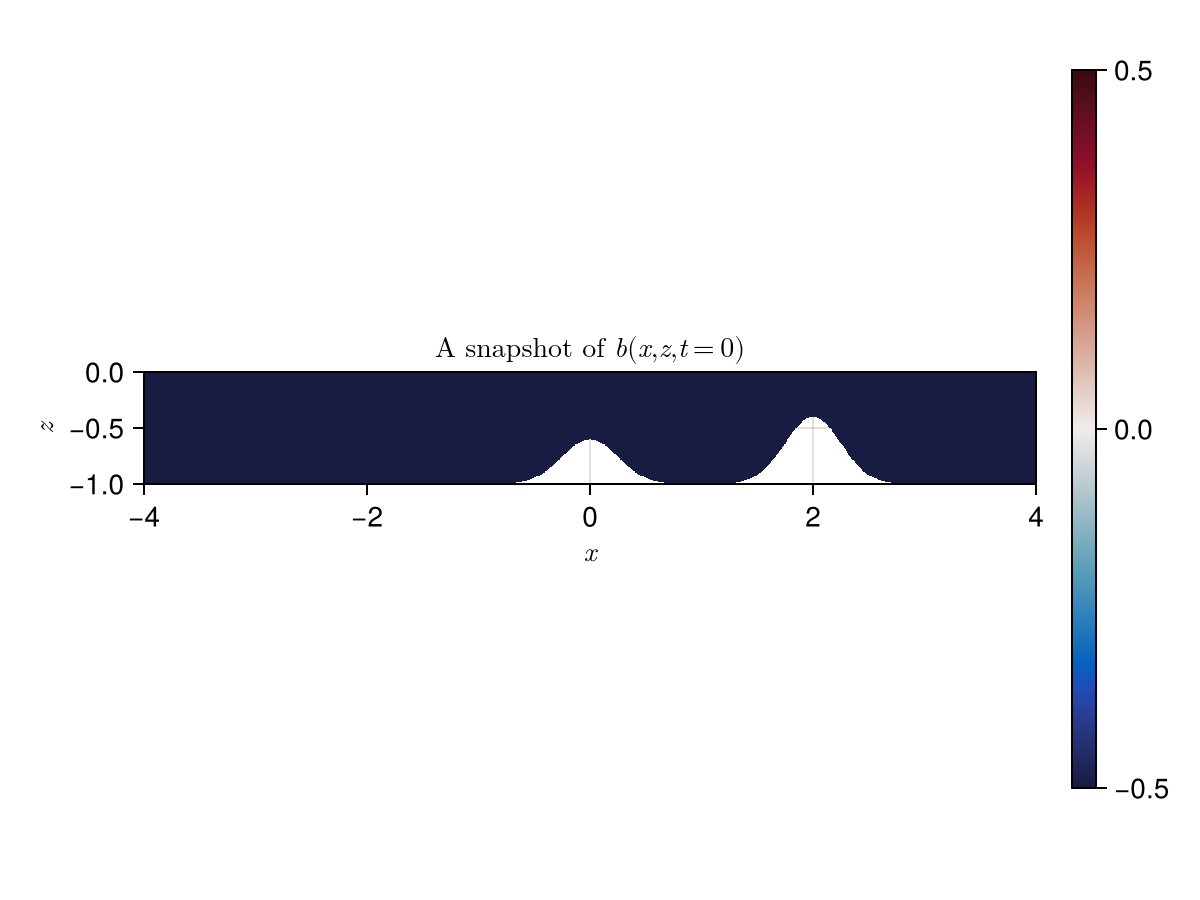

In [26]:
#okay lets plot a quick heatmap and see if that worked
#we should expect the buoyancy to be 0.5 everywhere and the hills to show up

f = Figure()
ax = Axis(f[1,1], aspect =8, xlabel = L"x", ylabel=L"z", title=L"\text{A snapshot of } b(x,z,t=0)")
hm = heatmap!(ax, x, z, b, colorrange=(-0.5, 0.5), colormap = :balance)
Colorbar(f[1,2], hm)
f

In [31]:
#okay z is already defined above, so now lets define z2d

z_3d = repeat(reshape(z, 1, 1, Nz), Nx, 1, 1);
b_flat = reshape(b, (Nx*Nz));
wet_flat = reshape(wet, (Nx*Nz));
z_flat = reshape(z_3d, (Nx*Nz));

In [32]:
#sort_idx is an array of indices that represents the sorted state of b_flat array
sort_idx = sortperm(b_flat);

#if we parse sort_idx through b_flat and z_flat then we get the SORTED b and z arrays

b_sorted, z_sorted = b_flat[sort_idx], z_flat[sort_idx];

In [62]:
] add Interpolations

   Resolving package versions...
  No Changes to `/dfs6/pub/ikeshwan/code/HorizontalConvection/Project.toml`
  No Changes to `/dfs6/pub/ikeshwan/code/HorizontalConvection/Manifest.toml`


In [94]:
#now we can reconstruct z* 
using Interpolations

ΔV_flat = ΔV[sort_idx];
size(ΔA)

A_wet = dropdims(sum(wet.*ΔA, dims=(2)), dims=(2));
A_interpolation = linear_interpolation(z, A_wet[:], extrapolation_bc=Line());

LoadError: DimensionMismatch: knot vectors must have the same axes as the corresponding dimension of the array

In [87]:
size(z)

(119,)

In [89]:
size(A_wet[:])

(951,)